In [1]:
import pandas as pd

doe = pd.read_csv('../data/raw/5184doe.csv')
randoms = pd.read_csv('../data/raw/1000randoms.csv')
semi = pd.read_csv('../data/raw/40semi-randoms.csv')

doe['source'] = 'doe'
randoms['source'] = 'random'
semi['source'] = 'semi-random'

df = pd.concat([doe, randoms, semi], ignore_index=True)
df.shape   # should be close to 5184 + 1000 + 40 = 6224 rows

(6224, 15)

In [4]:
df = pd.read_csv('../data/raw/5184doe.csv')
df = df.drop(columns=['Sample'])
print(df.shape)
print(df.columns)
print(df.head())

(5184, 13)
Index(['ecc', 'N', 'gammaG', 'Esoil', 'Econc', 'Dbot', 'H1', 'H2', 'H3',
       'Mr_t', 'Mt_t', 'Mr_c', 'Mt_c'],
      dtype='object')
   ecc     N  gammaG  Esoil  Econc  Dbot   H1   H2   H3      Mr_t      Mt_t  \
0    0  2000     0.9     25  30000    17  0.8  1.0  0.8  0.082100  0.055648   
1   10  2000     0.9     25  30000    17  0.8  1.0  0.8 -0.597084 -0.233470   
2   18  2000     0.9     25  30000    17  0.8  1.0  0.8 -1.094196 -0.566130   
3   26  2000     0.9     25  30000    17  0.8  1.0  0.8 -1.416485 -0.865039   
4    0  2000     0.9     25  37000    17  0.8  1.0  0.8  0.079570  0.054213   

       Mr_c      Mt_c  
0  0.082100  0.055648  
1  1.160648  0.605016  
2  1.908188  0.947770  
3  2.844706  1.310545  
4  0.079570  0.054213  


In [5]:
df.describe()

,ecc,N,gammaG,Esoil,Econc,Dbot,H1,H2,H3,Mr_t,Mt_t,Mr_c,Mt_c
count,5184.000000,5184.000000,5184.00000,5184.000000,5184.000000,5184.000000,5184.00000,5184.000000,5184.00000,5184.000000,5184.000000,5184.000000,5184.000000
mean,13.500000,3500.000000,1.00000,50.000000,33500.000000,20.000000,1.20000,1.500000,1.20000,-1.629734,-0.810779,2.650433,1.518741
std,9.631609,1500.144697,0.10001,25.002412,3500.337626,2.449726,0.32663,0.408288,0.32663,1.426607,0.859657,2.475025,1.226075
min,0.000000,2000.000000,0.90000,25.000000,30000.000000,17.000000,0.80000,1.000000,0.80000,-6.027412,-2.968574,0.024414,0.014080
25%,7.500000,2000.000000,0.90000,25.000000,30000.000000,17.000000,0.80000,1.000000,0.80000,-2.402849,-1.191169,0.251651,0.458440
50%,14.000000,3500.000000,1.00000,50.000000,33500.000000,20.000000,1.20000,1.500000,1.20000,-1.554450,-0.620024,2.138881,1.349318
75%,20.000000,5000.000000,1.10000,75.000000,37000.000000,23.000000,1.60000,2.000000,1.60000,-0.176328,0.018693,3.716968,2.413945
max,26.000000,5000.000000,1.10000,75.000000,37000.000000,23.000000,1.60000,2.000000,1.60000,0.251917,0.201895,9.408445,4.585227


<Axes: >

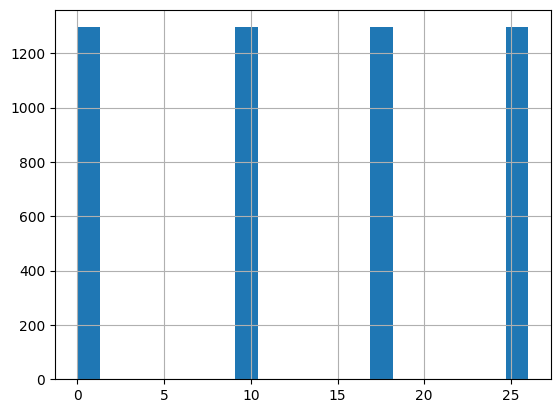

In [6]:
df['ecc'].hist(bins=20)

<Axes: >

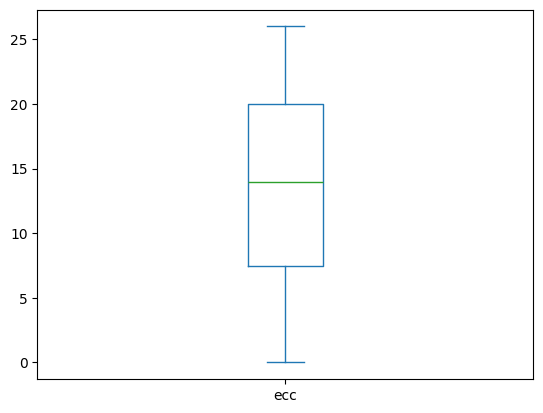

In [ ]:
df['ecc'].plot(kind='box') 

<Axes: >

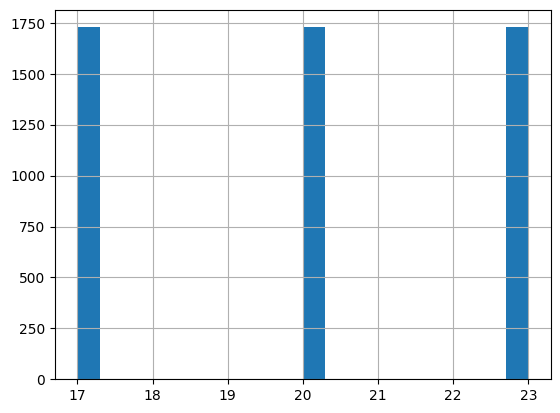

In [8]:
df['Dbot'].hist(bins=20)

<Axes: >

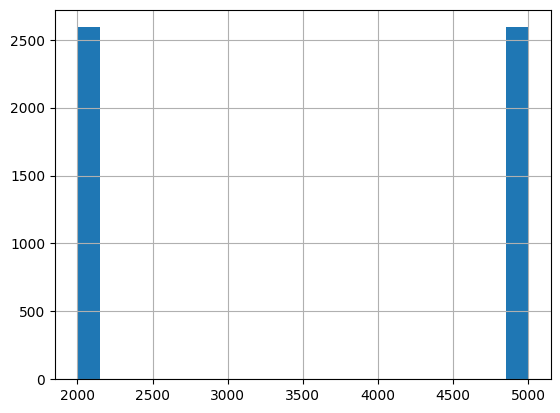

In [9]:
df['N'].hist(bins=20)

In [10]:
for col in df.columns:
    print(col, df[col].nunique())

ecc 4
N 2
gammaG 2
Esoil 2
Econc 2
Dbot 3
H1 3
H2 3
H3 3
Mr_t 4538
Mt_t 4539
Mr_c 4537
Mt_c 4540


<Axes: >

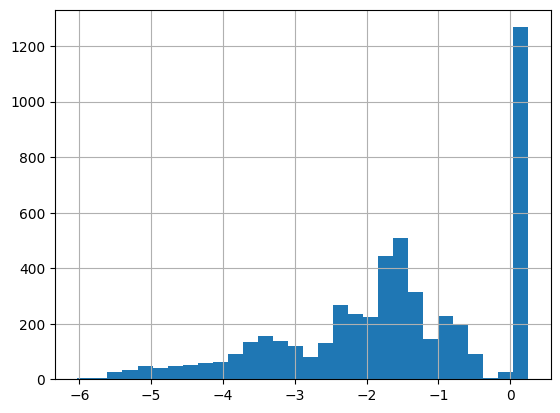

In [11]:
df['Mr_t'].hist(bins=30)

<Axes: >

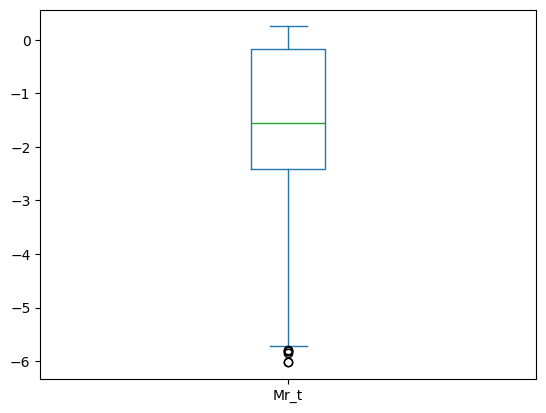

In [12]:
df['Mr_t'].plot(kind='box')

<Axes: >

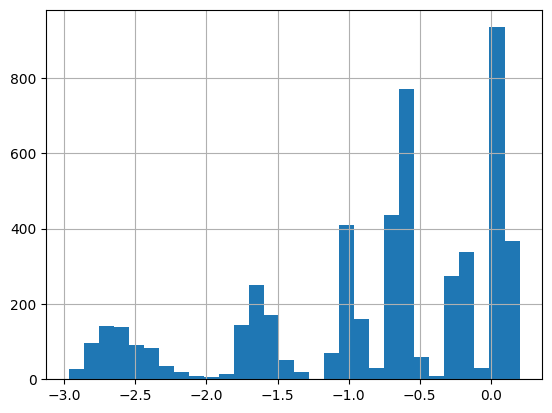

In [14]:
df['Mt_t'].hist(bins=30)


<Axes: >

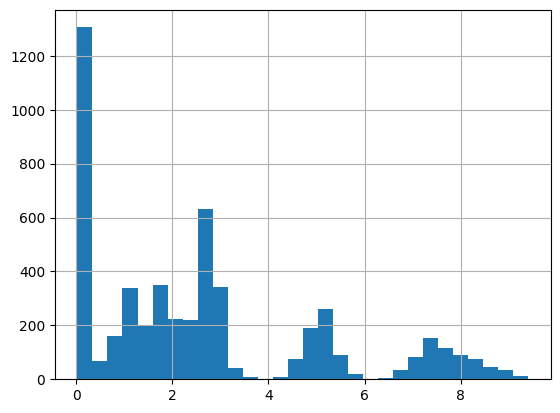

In [15]:
df['Mr_c'].hist(bins=30)


<Axes: >

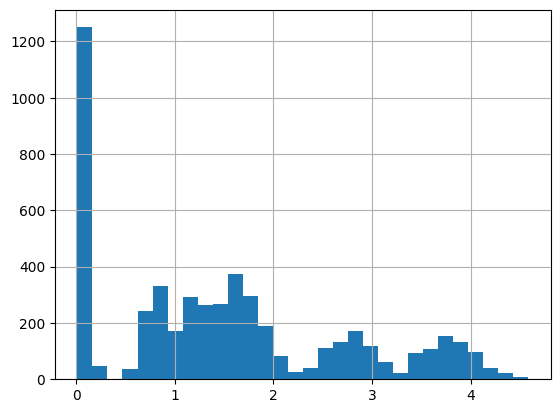

In [16]:
df['Mt_c'].hist(bins=30)

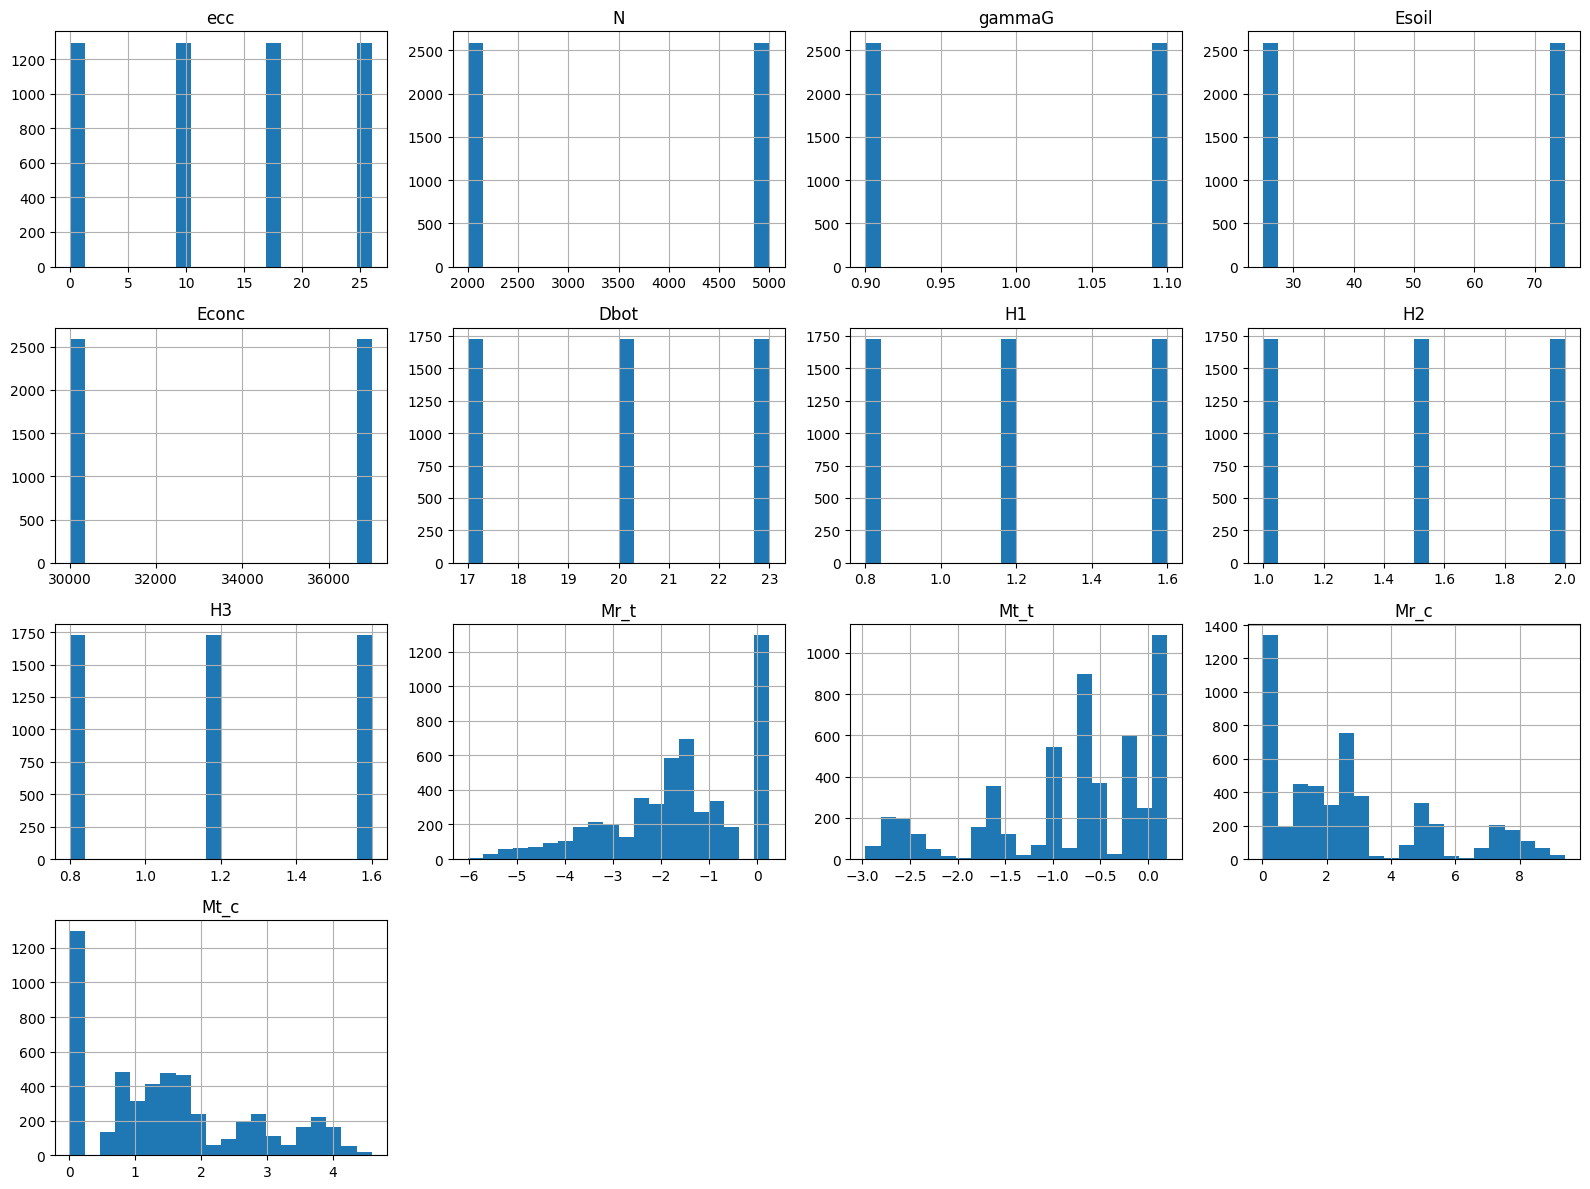

In [18]:
import matplotlib.pyplot as plt

 
df.hist(figsize=(16, 12), bins=20)
plt.tight_layout()
plt.show()

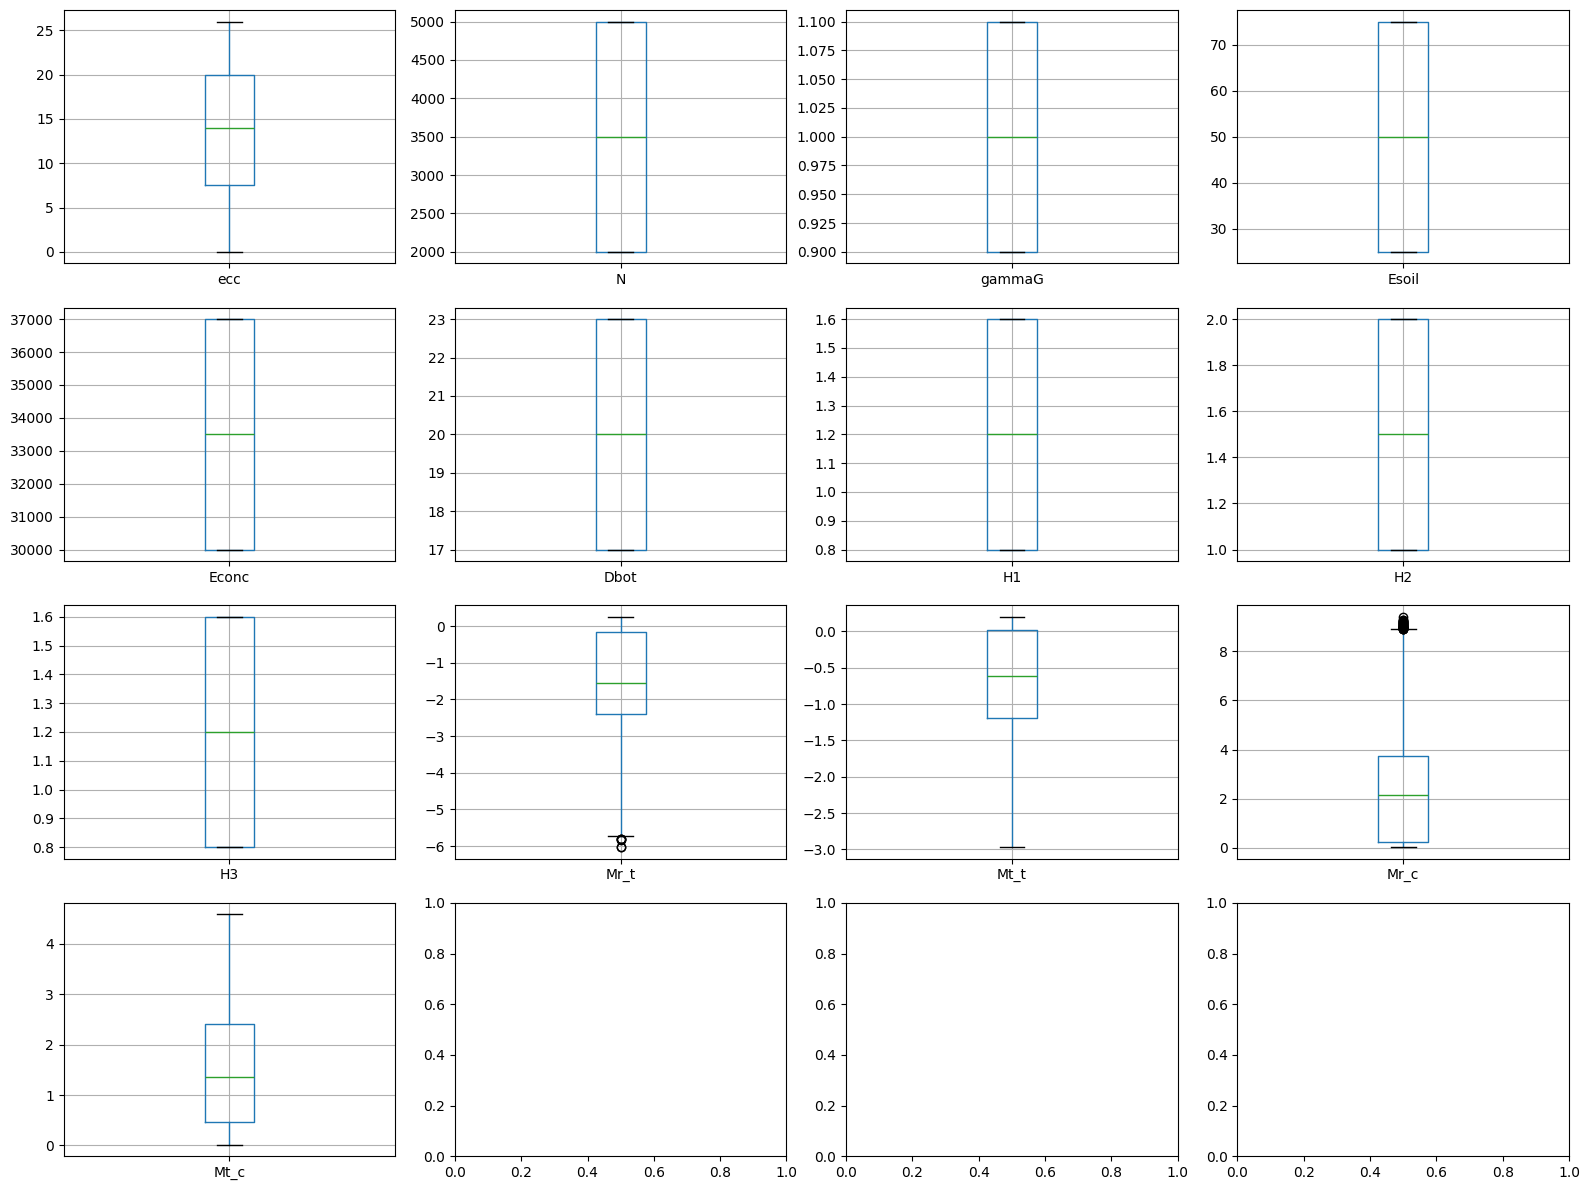

In [19]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    df.boxplot(column=col, ax=axes[i])

plt.tight_layout()
plt.show()

In [20]:
df.isnull().sum()

ecc       0
N         0
gammaG    0
Esoil     0
Econc     0
Dbot      0
H1        0
H2        0
H3        0
Mr_t      0
Mt_t      0
Mr_c      0
Mt_c      0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.dtypes

ecc         int64
N           int64
gammaG    float64
Esoil       int64
Econc       int64
Dbot        int64
H1        float64
H2        float64
H3        float64
Mr_t      float64
Mt_t      float64
Mr_c      float64
Mt_c      float64
dtype: object

In [23]:
df.to_csv('../data/processed/fem_cleaned.csv', index=False)